Info    : Reading './files/1D_mesh.msh'...
Info    : 3 entities
Info    : 101 nodes
Info    : 101 elements
Info    : Done reading './files/1D_mesh.msh'


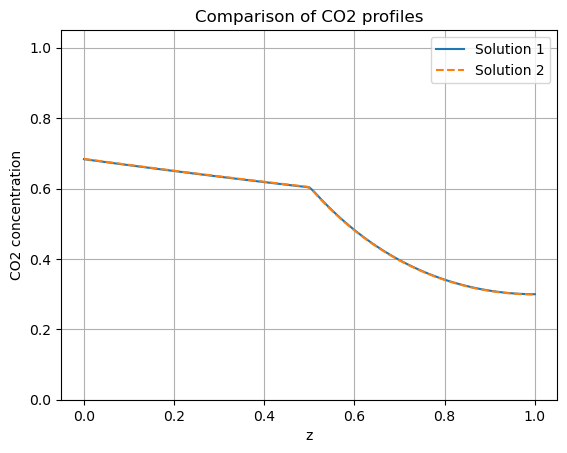

In [ ]:
import steady_solver as ss
import matplotlib.pyplot as plt 
import sys 
sys.path.append("../../modules/")
import leaf_model as lm

def compare_solution(z1, c1, z2, c2):
    plt.plot(z1, c1, label="Solution 1")
    plt.plot(z2, c2, label="Solution 2", linestyle='dashed')
    plt.xlabel("z")
    plt.ylabel("CO2 concentration")
    plt.title("Comparison of CO2 profiles")
    plt.legend()
    plt.grid()
    plt.ylim(0, 1.05)
    plt.show()

tau, gamma, chi_ = 1, 1, 0.1
rho = (0.1, 0.1, 0.5)
epsilon = 0.001
filename = "./files/run.bp"

leaf = lm.Leaf(tau, gamma, chi_, rho=rho)
domain, solution = leaf.calculate_steady_state_solution()

delta_ = lambda z: ss.step_down(z, min=leaf.deltas.min(), max=leaf.deltas.max(), offset=1-leaf.rho[2], epsilon=epsilon)
kappa_ = lambda z: ss.step_up(z, min=leaf.kappas.min(), max=leaf.kappas.max(), offset=1-leaf.rho[2], epsilon=epsilon)

ss.solver(tau, gamma, chi_, delta=delta_, kappa=kappa_, filename=filename)
z, c = ss.extract_solution(filename)
compare_solution(z, c, domain, solution)

